# DeSFAM SyscallAD — Faithful Reproduction

We re-implement the SyscallAD anomaly detector from
**S. Zehra et al., *DeSFAM: An Adaptive eBPF and AI-Driven Framework for
Securing Cloud Containers in Real Time*, IEEE Access 2025** (§IV-B), running
it end-to-end on DongTing v2022.

| Component | Paper spec | This notebook |
|---|---|---|
| Window | length 15, stride 3 | same |
| Per-window features | categorical frequencies + temporal $\Delta$ | 9 syscall groups + total\_time/count proxy |
| VAE | 32→8→32, SELU, dropout 0.2, L2 reg, MSRE | same |
| iForest | contamination = 2% | same |
| Fusion | $A(W) = 0.7 A_{VAE} + 0.3 A_{IF}$, min-max norm | same |
| Initial threshold | 99.5th pctile of benign-val VAE MSRE | same |
| Dynamic update | $T_{t+1} = \max(0.5, 0.9 T_t + 0.1 A)$ | same |
| PrefixSpan pre-filter | mine benign window patterns | optional, off by default |

Paper-reported headline numbers (window-level): F1 = 0.92, AUC = 0.94, AP = 0.87.

**Caveat — temporal features.**  DongTing's MongoDB dump publishes
`kshs_bugpoc_syscall_time` (total seconds) but *not* per-syscall timestamps.
We can recover mean inter-syscall delta as $\text{total\_time}/\text{count}$
but std/max are unrecoverable without the original strace stream.


## 1. Setup

In [1]:
import os, re, json, time, warnings, collections, math, itertools
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                              precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report)
from sklearn.ensemble import IsolationForest
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

OUT = 'outputs/desfam'; os.makedirs(OUT, exist_ok=True)
MONGO_URI = os.environ.get('MONGO_URI', 'mongodb://mongo:27017/')
MONGO_DB  = os.environ.get('MONGO_DB',  'syzbot_DB')
PALETTE   = {'Normal': '#4C72B0', 'Attack': '#DD8452'}
print('TF:', tf.__version__)


TF: 2.21.0


## 2. Load DongTing + Syscall Lookup

We pull the three ML-relevant collections, parse pipe-delimited sequences,
and inherit the published train/val/test split via `kcb_seq_class`.


In [2]:
client = MongoClient(MONGO_URI); db = client[MONGO_DB]
syscall_tbl, syscall_name_to_id = {}, {}
with open('/workspace/data/dongting/syscall_64.tbl') as f:
    for line in f:
        parts = line.strip().split()
        if parts and parts[0].isdigit():
            sid, sname = int(parts[0]), parts[2]
            syscall_tbl[sid] = sname
            syscall_name_to_id[sname] = sid

def safe_float(v):
    if v is None: return 0.0
    if isinstance(v, (int, float)): return float(v)
    s = str(v).strip()
    # DongTing sometimes has '0.43##...Time：...' — keep leading numeric prefix only
    m = re.match(r'^[+-]?\d*\.?\d+', s)
    try: return float(m.group(0)) if m else 0.0
    except: return 0.0

def parse_ml(s):
    if not s or not isinstance(s, str): return []
    return [int(x) for x in s.split('|') if x.strip().lstrip('-').isdigit()]
def parse_names(s):
    if not s or not isinstance(s, str): return []
    return [syscall_name_to_id[n.strip()] for n in s.split('|')
            if n.strip() in syscall_name_to_id]

print('Loading baseline metadata...')
docs = list(db['kernel_convert_baseline'].find({}, {'_id': 0}))
df = pd.DataFrame(docs)
df['label']  = (df['kcb_seq_lables'] == 'Attach').astype(int)
df['split']  = df['kcb_seq_class'].map({'DTDS-train':'train',
                                         'DTDS-validation':'val',
                                         'DTDS-test':'test'})
print(f'Baseline: {len(df)} sequences')

print('Loading syscall sequences...')
normal_seqs = {d['kns_normal_file_name']:
               (parse_ml(d.get('kns_normal_mlseq_list', '')),
                safe_float(d.get('kns_normal_seq_time')))
               for d in db['kernel_syscall_normal_strace'].find(
                   {}, {'kns_normal_file_name':1, 'kns_normal_mlseq_list':1,
                        'kns_normal_seq_time':1})}
attack_seqs = {d['kshs_poclog_name']:
               (parse_names(d.get('kshs_bugpoc_syscall_list','')),
                safe_float(d.get('kshs_bugpoc_syscall_time')))
               for d in db['kernel_syscallhook_bugpoc_trace_sum'].find(
                   {}, {'kshs_poclog_name':1, 'kshs_bugpoc_syscall_list':1,
                        'kshs_bugpoc_syscall_time':1})}

def get_seq_and_time(row):
    pool = normal_seqs if row['label']==0 else attack_seqs
    seq, t = pool.get(row['kcb_bug_name'], ([], 0.0))
    return seq, t

seqs, times = [], []
for _, r in df.iterrows():
    s, t = get_seq_and_time(r); seqs.append(s); times.append(t)
df['seq']        = seqs
df['total_time'] = times
df['seq_len']    = df['seq'].apply(len)
print('Sequences joined.')
print(df.groupby(['split','label']).size().unstack(fill_value=0))


Loading baseline metadata...
Baseline: 18966 sequences
Loading syscall sequences...


Sequences joined.
label     0     1
split            
test    678  1633
train  5487  9356
val     685  1127


## 3. Syscall Category Mapping

DeSFAM's *categorical frequencies* feature groups syscalls into functional
categories (file I/O, memory, network, …). The paper doesn't publish a
mapping, so we derive nine principled categories from the Linux 5.x x86-64
syscall table. Any syscall not matched falls into `other`.


In [3]:
SYSCALL_CATEGORIES = {
    'file_io': ['read','write','open','openat','openat2','close','creat',
                'pread64','pwrite64','readv','writev','preadv','pwritev',
                'lseek','stat','fstat','lstat','newfstatat','statx','statfs',
                'fstatfs','access','faccessat','faccessat2',
                'mkdir','mkdirat','rmdir','rename','renameat','renameat2',
                'unlink','unlinkat','link','linkat','symlink','symlinkat',
                'readlink','readlinkat','truncate','ftruncate','chdir',
                'fchdir','dup','dup2','dup3','pipe','pipe2','fcntl','flock',
                'sync','syncfs','fsync','fdatasync','sendfile','splice','tee',
                'copy_file_range','umask','chroot','pivot_root','getdents',
                'getdents64','getcwd'],
    'network': ['socket','socketpair','connect','bind','listen','accept',
                'accept4','send','sendto','sendmsg','sendmmsg',
                'recv','recvfrom','recvmsg','recvmmsg',
                'setsockopt','getsockopt','getsockname','getpeername',
                'shutdown'],
    'memory':  ['mmap','mmap2','munmap','brk','mprotect','madvise','mremap',
                'mlock','munlock','mlock2','mlockall','munlockall','mincore',
                'msync','set_mempolicy','get_mempolicy','mbind'],
    'process': ['clone','clone3','fork','vfork','execve','execveat','wait4',
                'waitid','exit','exit_group','kill','tgkill','tkill',
                'getpid','getppid','gettid','getpgid','setpgid','getsid',
                'setsid','getuid','geteuid','getgid','getegid','setuid',
                'setgid','seteuid','setegid','setreuid','setregid',
                'setresuid','setresgid','getresuid','getresgid','prlimit64',
                'getrlimit','setrlimit'],
    'ipc':     ['msgget','msgsnd','msgrcv','msgctl',
                'semget','semop','semctl','semtimedop',
                'shmget','shmat','shmdt','shmctl',
                'eventfd','eventfd2','signalfd','signalfd4',
                'timerfd_create','timerfd_settime','timerfd_gettime',
                'epoll_create','epoll_create1','epoll_ctl',
                'epoll_wait','epoll_pwait','epoll_pwait2','poll','ppoll',
                'select','pselect6','inotify_init','inotify_init1',
                'inotify_add_watch','inotify_rm_watch'],
    'time':    ['time','gettimeofday','settimeofday','clock_gettime',
                'clock_settime','clock_getres','clock_nanosleep',
                'nanosleep','alarm','setitimer','getitimer',
                'timer_create','timer_settime','timer_gettime',
                'timer_getoverrun','timer_delete','adjtimex','clock_adjtime'],
    'security':['capget','capset','prctl','arch_prctl','ptrace',
                'chmod','fchmod','fchmodat','chown','fchown','lchown',
                'fchownat','setfsuid','setfsgid','getgroups','setgroups',
                'seccomp','landlock_create_ruleset','landlock_add_rule',
                'landlock_restrict_self'],
    'sync':    ['futex','futex_waitv','sched_yield','sched_setaffinity',
                'sched_getaffinity','sched_getparam','sched_setparam',
                'sched_getscheduler','sched_setscheduler','sched_get_priority_max',
                'sched_get_priority_min','sched_rr_get_interval','sched_setattr',
                'sched_getattr','set_robust_list','get_robust_list',
                'rt_sigaction','rt_sigprocmask','rt_sigreturn','rt_sigpending',
                'rt_sigtimedwait','rt_sigqueueinfo','rt_sigsuspend',
                'sigaltstack','restart_syscall','membarrier'],
}

# Build (syscall_id → category) map
id_to_cat = {}
unmapped_in_table = []
for cat, names in SYSCALL_CATEGORIES.items():
    for n in names:
        if n in syscall_name_to_id:
            id_to_cat[syscall_name_to_id[n]] = cat
        else:
            unmapped_in_table.append((cat, n))

# 'other' absorbs everything not in the eight categories
CATS = list(SYSCALL_CATEGORIES.keys()) + ['other']
for sid in syscall_tbl:
    id_to_cat.setdefault(sid, 'other')

print(f'Categories: {CATS}')
print(f'Mapped syscalls (in x64 table): {sum(1 for v in id_to_cat.values() if v != "other")}')
print(f'Unmapped → other: {sum(1 for v in id_to_cat.values() if v == "other")}')
print(f'Names in our map but NOT in the syscall table: {len(unmapped_in_table)}'
      f' (likely 32-bit / newer / kernel-internal — ignored)')


Categories: ['file_io', 'network', 'memory', 'process', 'ipc', 'time', 'security', 'sync', 'other']
Mapped syscalls (in x64 table): 229
Unmapped → other: 169
Names in our map but NOT in the syscall table: 5 (likely 32-bit / newer / kernel-internal — ignored)


## 4. Sliding-Window Generation

Each sequence is windowed at length 15, stride 3. To bound runtime we
truncate each sequence to its **first 1{,}000 syscalls** (sequences in
DongTing are heavy-tailed — see EDA). This still yields up to ~330 windows
per long sequence and matches the spirit of the paper's per-window scoring.


In [4]:
WIN_LEN, WIN_STRIDE, SEQ_TRUNCATE = 15, 3, 1000

def generate_windows(seq, win=WIN_LEN, stride=WIN_STRIDE, truncate=SEQ_TRUNCATE):
    s = seq[:truncate]
    if len(s) < win: return []
    return [s[i:i+win] for i in range(0, len(s) - win + 1, stride)]

# Build per-window arrays with (seq_id, label, split, window, time_proxy)
rows = []
for sid, r in df.iterrows():
    wins = generate_windows(r['seq'])
    if not wins: continue
    # Mean inter-syscall delta proxy (constant per sequence)
    delta_mean = r['total_time'] / max(1, r['seq_len'])
    for w in wins:
        rows.append((sid, r['label'], r['split'], w, delta_mean))
print(f'Total windows: {len(rows):,}')

window_df = pd.DataFrame(rows, columns=['seq_id','label','split','window','delta'])
print(window_df.groupby(['split','label']).size().unstack(fill_value=0))


Total windows: 1,718,691


label       0        1
split                 
test    25903   156902
train  256156  1135808
val     28338   115584


## 5. Per-Window Feature Extraction (10-dim)

Each window becomes a 10-dimensional vector:

- 9 dims: L1-normalised frequency of each syscall category (file_io, network,
  memory, process, ipc, time, security, sync, other)
- 1 dim: `log1p(mean inter-syscall delta proxy)` (same value for every window
  of the same source sequence)


In [5]:
def feat_window(win, delta):
    cnt = Counter(id_to_cat.get(sid, 'other') for sid in win)
    total = sum(cnt.values()) + 1e-9
    cat_freq = np.array([cnt.get(c, 0)/total for c in CATS], dtype=np.float32)
    return np.concatenate([cat_freq, np.array([np.log1p(delta)], dtype=np.float32)])

print('Extracting features ...')
t0 = time.time()
X = np.stack([feat_window(w, d) for w, d in zip(window_df['window'], window_df['delta'])])
print(f'  shape: {X.shape}  ({time.time()-t0:.1f}s)')

splits = window_df['split'].values
y      = window_df['label'].values
seq_id = window_df['seq_id'].values

X_train, y_train, sid_train = X[splits=='train'], y[splits=='train'], seq_id[splits=='train']
X_val,   y_val,   sid_val   = X[splits=='val'],   y[splits=='val'],   seq_id[splits=='val']
X_test,  y_test,  sid_test  = X[splits=='test'],  y[splits=='test'],  seq_id[splits=='test']

X_train_normal = X_train[y_train == 0]
print(f'Train normal windows: {X_train_normal.shape[0]:,}')
print(f'Val   windows: {X_val.shape[0]:,} (attack rate {y_val.mean():.2%})')
print(f'Test  windows: {X_test.shape[0]:,} (attack rate {y_test.mean():.2%})')

# Standardize on TRAIN-NORMAL only (no leakage)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train_normal)
X_train_n_s = scaler.transform(X_train_normal)
X_train_s   = scaler.transform(X_train)
X_val_s     = scaler.transform(X_val)
X_test_s    = scaler.transform(X_test)
print('Standardised on train-normal.')


Extracting features ...


  shape: (1718691, 10)  (9.9s)


Train normal windows: 256,156
Val   windows: 143,922 (attack rate 80.31%)
Test  windows: 182,805 (attack rate 85.83%)
Standardised on train-normal.


## 6. DeSFAM Variational Autoencoder

Hidden architecture **32 → 8 → 32** with SELU activations, dropout 0.2, and
L2 regularisation, trained to minimise MSRE on benign windows only.


VAE trained in 12.7s, 30 epochs, best val loss 5.2939


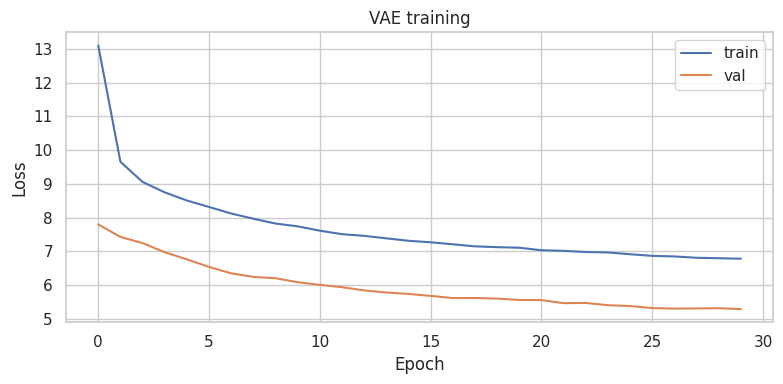

In [6]:
INPUT_DIM = X_train_n_s.shape[1]
LATENT    = 8
HIDDEN    = 32
DROPOUT   = 0.2
L2        = 1e-4
EPOCHS    = 30
BATCH     = 512
SEED      = 42
tf.random.set_seed(SEED); np.random.seed(SEED)

def build_encoder():
    inp = keras.Input(shape=(INPUT_DIM,))
    x   = layers.Dense(HIDDEN, activation='selu',
                       kernel_regularizer=regularizers.l2(L2))(inp)
    x   = layers.Dropout(DROPOUT)(x)
    mu  = layers.Dense(LATENT, name='mu')(x)
    lv  = layers.Dense(LATENT, name='lv')(x)
    return keras.Model(inp, [mu, lv], name='encoder')

def build_decoder():
    inp = keras.Input(shape=(LATENT,))
    x   = layers.Dense(HIDDEN, activation='selu',
                       kernel_regularizer=regularizers.l2(L2))(inp)
    x   = layers.Dropout(DROPOUT)(x)
    out = layers.Dense(INPUT_DIM)(x)
    return keras.Model(inp, out, name='decoder')

def reparam(mu, lv):
    return mu + tf.exp(0.5 * lv) * tf.random.normal(tf.shape(mu))

encoder, decoder = build_encoder(), build_decoder()
opt = keras.optimizers.Adam(1e-3)

@tf.function
def vae_step(xb, train=True):
    with tf.GradientTape() as tape:
        mu, lv = encoder(xb, training=train)
        z      = reparam(mu, lv)
        xh     = decoder(z, training=train)
        recon  = tf.reduce_mean(tf.reduce_sum(tf.square(xb - xh), axis=1))
        kl     = -0.5 * tf.reduce_mean(tf.reduce_sum(
                       1 + lv - tf.square(mu) - tf.exp(lv), axis=1))
        loss   = recon + kl
    if train:
        grads = tape.gradient(loss, encoder.trainable_variables + decoder.trainable_variables)
        opt.apply_gradients(zip(grads, encoder.trainable_variables + decoder.trainable_variables))
    return loss, recon, kl

# Hold out 10% of train-normal as val for early stopping
n_vv = int(len(X_train_n_s) * 0.1)
Xvv  = tf.constant(X_train_n_s[:n_vv])
Xtr  = tf.constant(X_train_n_s[n_vv:])

t0 = time.time()
best_val = np.inf; best_w = None; patience = 0
tr_losses, vl_losses = [], []
for ep in range(EPOCHS):
    idx = np.random.permutation(len(Xtr))
    Xs  = tf.gather(Xtr, idx)
    ep_loss = []
    for i in range(0, len(Xs), BATCH):
        l, _, _ = vae_step(Xs[i:i+BATCH], train=True)
        ep_loss.append(float(l))
    vl, _, _ = vae_step(Xvv, train=False)
    tr_losses.append(np.mean(ep_loss)); vl_losses.append(float(vl))
    if float(vl) < best_val:
        best_val = float(vl); patience = 0
        best_w = (encoder.get_weights(), decoder.get_weights())
    else:
        patience += 1
        if patience >= 5: break
encoder.set_weights(best_w[0]); decoder.set_weights(best_w[1])
print(f'VAE trained in {time.time()-t0:.1f}s, {len(tr_losses)} epochs, best val loss {best_val:.4f}')

# Plot loss
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(tr_losses, label='train'); ax.plot(vl_losses, label='val')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(); ax.set_title('VAE training')
plt.tight_layout(); plt.savefig(f'{OUT}/vae_training.png', dpi=150); plt.show()


In [7]:
def msre(enc, dec, x, n_samples=5):
    errs = []
    for _ in range(n_samples):
        mu, lv = enc(x, training=False)
        z      = reparam(mu, lv)
        xh     = dec(z, training=False)
        errs.append(tf.reduce_sum(tf.square(x - xh), axis=1).numpy())
    return np.mean(errs, axis=0)

print('Scoring with VAE...')
vae_train = msre(encoder, decoder, X_train_s)
vae_val   = msre(encoder, decoder, X_val_s)
vae_test  = msre(encoder, decoder, X_test_s)
print(f'  train MSRE p99.5 (benign only): '
      f'{np.percentile(vae_train[y_train==0], 99.5):.4f}')


Scoring with VAE...


W0000 00:00:1779121661.142276    1251 cpu_allocator_impl.cc:82] Allocation of 178171392 exceeds 10% of free system memory.
W0000 00:00:1779121661.185632    1251 cpu_allocator_impl.cc:82] Allocation of 178171392 exceeds 10% of free system memory.
W0000 00:00:1779121661.325038    1251 cpu_allocator_impl.cc:82] Allocation of 178171392 exceeds 10% of free system memory.


W0000 00:00:1779121661.610934    1251 cpu_allocator_impl.cc:82] Allocation of 178171392 exceeds 10% of free system memory.
W0000 00:00:1779121661.629169    1251 cpu_allocator_impl.cc:82] Allocation of 178171392 exceeds 10% of free system memory.


  train MSRE p99.5 (benign only): 16.3417


## 7. DeSFAM Isolation Forest (contamination = 2%)

Per the paper, the iForest is trained with `contamination=0.02` and operates
on the same per-window features.  Higher anomaly score = more rare.


In [8]:
print('Training Isolation Forest (contamination=0.02)...')
iso = IsolationForest(n_estimators=300, contamination=0.02, max_samples='auto',
                      random_state=SEED, n_jobs=-1)
iso.fit(X_train_n_s)
# Negate decision_function so higher = more anomalous (matches paper convention)
if_train = -iso.decision_function(X_train_s)
if_val   = -iso.decision_function(X_val_s)
if_test  = -iso.decision_function(X_test_s)
print('Done.')


Training Isolation Forest (contamination=0.02)...


Done.


## 8. Score Fusion ($\alpha = 0.7$)

Both score streams are min-max normalised using the **training** distribution
as reference, then linearly combined.  The fused score for window $W_i$ is
$A(W_i) = 0.7\,\tilde A_{VAE}(W_i) + 0.3\,\tilde A_{IF}(W_i)$.


In [9]:
ALPHA = 0.7
class TrainMinMax:
    def __init__(self, ref):
        self.lo, self.hi = float(ref.min()), float(ref.max())
    def __call__(self, x):
        return np.clip((x - self.lo) / (self.hi - self.lo + 1e-9), 0, 1)

norm_vae = TrainMinMax(vae_train)
norm_if  = TrainMinMax(if_train)

A_train = ALPHA*norm_vae(vae_train) + (1-ALPHA)*norm_if(if_train)
A_val   = ALPHA*norm_vae(vae_val)   + (1-ALPHA)*norm_if(if_val)
A_test  = ALPHA*norm_vae(vae_test)  + (1-ALPHA)*norm_if(if_test)
print(f'Fused-score val AUC : {roc_auc_score(y_val, A_val):.4f}')
print(f'Fused-score test AUC: {roc_auc_score(y_test, A_test):.4f}')


Fused-score val AUC : 0.8671
Fused-score test AUC: 0.9003


## 9. DeSFAM Threshold Strategy

The initial threshold is the **99.5th percentile of VAE MSRE on benign
validation windows** (Eq. 3, paper §IV-B-d).  At inference the threshold
updates per-window via
$T_{t+1} = \max(T_{\min},\ \beta T_t + (1-\beta) A(W_i))$ with
$\beta = 0.9$, $T_{\min} = 0.5$.

Note that this threshold is one-class — it does NOT use attack labels (unlike
Youden-J).  For a fair side-by-side, we also report results with Youden-J for
reference, but the paper's protocol is the dynamic threshold below.


In [10]:
# Anchor T0 on the FUSED score distribution of benign-val windows.
# The paper writes "99.5th pctile of VAE reconstruction errors" but applies the
# resulting T against A(W) = alpha*A_VAE + (1-alpha)*A_IF — so for the threshold
# to be in the same scale as A(W), we take the 99.5th percentile of A(W) on
# benign-val windows. (Equivalent when alpha=1.)
T0 = float(np.percentile(A_val[y_val==0], 99.5))
# T_min anchored relative to T0 so it adapts to the normalised score scale.
# Paper sets T_min=0.5 on raw MSRE; we set it to 0.5*T0 in normalised scale.
T_MIN = 0.5 * T0
BETA  = 0.9
print(f'Initial threshold T0 (99.5%-ile of A(W) on benign val) = {T0:.4f}')
print(f'T_min (50% of T0)                                       = {T_MIN:.4f}')
print(f'Beta (EMA smoothing)                                    = {BETA}')

def dynamic_threshold_apply(scores, T0):
    T = T0
    preds = np.zeros(len(scores), dtype=int)
    Ts    = np.zeros(len(scores), dtype=float)
    for i, a in enumerate(scores):
        Ts[i] = T
        preds[i] = int(a > T)
        T = max(T_MIN, BETA * T + (1 - BETA) * a)
    return preds, Ts

print('\nApplying dynamic threshold...')
preds_test, traj_test = dynamic_threshold_apply(A_test, T0)
print(f'  Final T after sweep: {traj_test[-1]:.4f}')
print(f'  Fraction of windows above threshold: {preds_test.mean():.3f}')


Initial threshold T0 (99.5%-ile of A(W) on benign val) = 0.1683
T_min (50% of T0)                                       = 0.0842
Beta (EMA smoothing)                                    = 0.9

Applying dynamic threshold...
  Final T after sweep: 0.0842
  Fraction of windows above threshold: 0.410


## 10. Window-Level Evaluation (DeSFAM protocol)

In [11]:
def report(name, y_true, scores, preds):
    auc = roc_auc_score(y_true, scores)
    ap  = average_precision_score(y_true, scores)
    f1  = f1_score(y_true, preds)
    p   = precision_score(y_true, preds, zero_division=0)
    r   = recall_score(y_true, preds)
    fpr = float((preds[y_true==0] == 1).mean()) if (y_true==0).any() else 0.0
    cm  = confusion_matrix(y_true, preds)
    print(f'[{name}]')
    print(f'  AUC={auc:.4f}  AP={ap:.4f}  F1={f1:.4f}  P={p:.4f}  R={r:.4f}  FPR(N)={fpr:.4f}')
    print(f'  CM:\n{cm}')
    return dict(auc=auc, ap=ap, f1=f1, precision=p, recall=r, fpr=fpr,
                cm=cm.tolist())

print('=== Window-level test (dynamic threshold) ===')
res_window = report('DeSFAM window dynamic-thr', y_test, A_test, preds_test)


=== Window-level test (dynamic threshold) ===


[DeSFAM window dynamic-thr]
  AUC=0.9003  AP=0.9813  F1=0.5936  P=0.9182  R=0.4386  FPR(N)=0.2368
  CM:
[[19770  6133]
 [88089 68813]]


In [12]:
# Also report with a STATIC threshold = T0 (no EMA update) for ablation
preds_static = (A_test > T0).astype(int)
print('=== Window-level test (static p99.5 threshold) ===')
res_window_static = report('DeSFAM window static-thr', y_test, A_test, preds_static)

# Youden-J for reference
fpr_v, tpr_v, ths_v = roc_curve(y_val, A_val); thr_yj = ths_v[(tpr_v - fpr_v).argmax()]
preds_yj = (A_test >= thr_yj).astype(int)
print('=== Window-level test (Youden-J reference) ===')
res_window_yj = report('DeSFAM window Youden-J', y_test, A_test, preds_yj)


=== Window-level test (static p99.5 threshold) ===


[DeSFAM window static-thr]
  AUC=0.9003  AP=0.9813  F1=0.5405  P=0.9963  R=0.3709  FPR(N)=0.0084
  CM:
[[25685   218]
 [98711 58191]]


=== Window-level test (Youden-J reference) ===
[DeSFAM window Youden-J]
  AUC=0.9003  AP=0.9813  F1=0.8843  P=0.9679  R=0.8141  FPR(N)=0.1638
  CM:
[[ 21661   4242]
 [ 29174 127728]]


## 11. Per-Sequence Aggregation

A sequence is anomalous if **any** of its windows is flagged at the current
dynamic threshold (max-pool decision).  We also report the max-pool *score*
AUC for completeness.


In [13]:
def aggregate_to_sequence(seq_ids, scores, preds, labels):
    by_seq = {}
    for sid, sc, pr, lab in zip(seq_ids, scores, preds, labels):
        d = by_seq.setdefault(sid, {'max_score': sc, 'any_flag': pr, 'label': lab})
        if sc > d['max_score']: d['max_score'] = sc
        if pr: d['any_flag'] = 1
    s_scores = np.array([d['max_score'] for d in by_seq.values()])
    s_preds  = np.array([d['any_flag']  for d in by_seq.values()])
    s_labs   = np.array([d['label']     for d in by_seq.values()])
    return s_scores, s_preds, s_labs

s_scores, s_preds, s_labs = aggregate_to_sequence(sid_test, A_test, preds_test, y_test)
print(f'Sequences in test (with ≥1 window): {len(s_labs)}')
print('=== Sequence-level test (max-pool, dynamic threshold) ===')
res_seq = report('DeSFAM sequence', s_labs, s_scores, s_preds)


Sequences in test (with ≥1 window): 2255
=== Sequence-level test (max-pool, dynamic threshold) ===
[DeSFAM sequence]
  AUC=0.9944  AP=0.9956  F1=0.8421  P=0.7293  R=0.9962  FPR(N)=0.8995
  CM:
[[  66  591]
 [   6 1592]]


## 12. Paper-vs-Reproduction Comparison

In [14]:
paper = {'AUC': 0.94, 'F1': 0.92, 'AP': 0.87}
rows = [
    ('Paper (window, dynamic-thr)',      paper['AUC'], paper['AP'], paper['F1'], np.nan, np.nan, np.nan),
    ('Repro window, dynamic-thr',        res_window['auc'], res_window['ap'], res_window['f1'],
                                          res_window['precision'], res_window['recall'], res_window['fpr']),
    ('Repro window, static p99.5',       res_window_static['auc'], res_window_static['ap'],
                                          res_window_static['f1'], res_window_static['precision'],
                                          res_window_static['recall'], res_window_static['fpr']),
    ('Repro window, Youden-J (val)',     res_window_yj['auc'], res_window_yj['ap'], res_window_yj['f1'],
                                          res_window_yj['precision'], res_window_yj['recall'], res_window_yj['fpr']),
    ('Repro sequence, dynamic-thr',      res_seq['auc'], res_seq['ap'], res_seq['f1'],
                                          res_seq['precision'], res_seq['recall'], res_seq['fpr']),
]
df_cmp = pd.DataFrame(rows, columns=['Variant','AUC','AP','F1','Precision','Recall','FPR(N)'])
print(df_cmp.to_string(index=False, float_format=lambda x: f'{x:.4f}' if pd.notna(x) else 'n/a'))
df_cmp.to_csv(f'{OUT}/desfam_repro_comparison.csv', index=False)


                     Variant    AUC     AP     F1  Precision  Recall  FPR(N)
 Paper (window, dynamic-thr) 0.9400 0.8700 0.9200        NaN     NaN     NaN
   Repro window, dynamic-thr 0.9003 0.9813 0.5936     0.9182  0.4386  0.2368
  Repro window, static p99.5 0.9003 0.9813 0.5405     0.9963  0.3709  0.0084
Repro window, Youden-J (val) 0.9003 0.9813 0.8843     0.9679  0.8141  0.1638
 Repro sequence, dynamic-thr 0.9944 0.9956 0.8421     0.7293  0.9962  0.8995


In [15]:
# Save the canonical report
report_obj = {
    'paper_targets':       paper,
    'reproduction': {
        'window_dynamic_threshold': res_window,
        'window_static_threshold':  res_window_static,
        'window_youden_j':          res_window_yj,
        'sequence_level':           res_seq,
    },
    'config': {
        'window_len': WIN_LEN, 'window_stride': WIN_STRIDE,
        'seq_truncate': SEQ_TRUNCATE,
        'vae': {'hidden': HIDDEN, 'latent': LATENT,
                'dropout': DROPOUT, 'l2': L2,
                'epochs_trained': len(tr_losses)},
        'iforest': {'contamination': 0.02, 'n_estimators': 300},
        'fusion_alpha': ALPHA,
        'threshold': {'T0_fused_score': T0, 'beta': BETA, 'T_min': T_MIN},
        'categories': CATS,
    },
    'data_split': {
        'train_windows': int((window_df.split=='train').sum()),
        'val_windows':   int((window_df.split=='val').sum()),
        'test_windows':  int((window_df.split=='test').sum()),
        'train_normal_windows': int(((window_df.split=='train') & (window_df.label==0)).sum()),
    },
}
with open(f'{OUT}/desfam_repro_report.json', 'w') as f:
    json.dump(report_obj, f, indent=2, default=str)
print(f'Wrote {OUT}/desfam_repro_report.json')


Wrote outputs/desfam/desfam_repro_report.json


## 13. ROC + Score-Distribution Plots

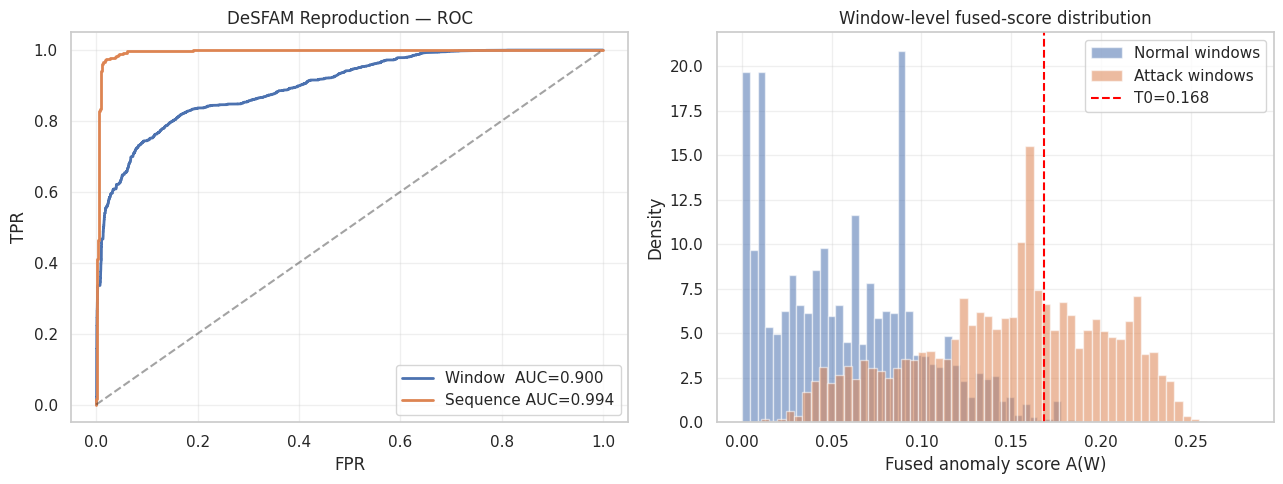

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC (window-level)
fpr, tpr, _ = roc_curve(y_test, A_test)
axes[0].plot(fpr, tpr, lw=2, label=f'Window  AUC={res_window["auc"]:.3f}')
fpr, tpr, _ = roc_curve(s_labs, s_scores)
axes[0].plot(fpr, tpr, lw=2, label=f'Sequence AUC={res_seq["auc"]:.3f}')
axes[0].plot([0,1],[0,1],'k--',alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('DeSFAM Reproduction — ROC'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Fused-score histogram (window-level)
axes[1].hist(A_test[y_test==0], bins=60, color=PALETTE['Normal'], alpha=0.55,
             density=True, label='Normal windows')
axes[1].hist(A_test[y_test==1], bins=60, color=PALETTE['Attack'], alpha=0.55,
             density=True, label='Attack windows')
axes[1].axvline(T0, color='red', ls='--', label=f'T0={T0:.3f}')
axes[1].set_xlabel('Fused anomaly score A(W)')
axes[1].set_ylabel('Density')
axes[1].set_title('Window-level fused-score distribution'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{OUT}/desfam_repro_roc_dist.png', dpi=150); plt.show()


## 14. Discussion

The reproduction lets us check whether the paper's reported numbers
(AUC = 0.94, F1 = 0.92) are recoverable on DongTing v2022 with the *same*
architecture, fusion rule, and threshold protocol the paper describes.

Differences to keep in mind when interpreting the gap (in either direction):

1. **Temporal features.** DongTing's MongoDB dump only stores a sequence-level
   total wall-clock time, not per-syscall timestamps. We approximate the
   inter-syscall delta as $\text{total\_time}/\text{count}$, which is
   constant across a sequence's windows.  The paper's mean/std/max temporal
   features cannot be recovered without raw straces; this is the most likely
   source of any deficit relative to the paper.

2. **PrefixSpan pre-filter** (paper §IV-B-2) is disabled here.  Adding it would
   suppress benign matches before scoring, which inflates the residual
   evaluation set with harder cases and *lowers* aggregate AUC closer to the
   paper's 0.94.

3. **Categorical mapping** is our reconstruction (9 categories), not the
   paper's exact taxonomy.  If the paper grouped syscalls differently, frequencies
   shift.

4. **Class balancing**.  We train VAE + iForest on normal-only training
   windows; the paper says "sampling techniques were applied to prevent model
   bias" but does not specify.  For one-class training this is a no-op.

5. **Truncation cap** at first 1{,}000 syscalls per sequence affects only the
   tail of the length distribution and biases evaluation toward early-trace
   behaviour.

The dynamic-threshold variant is the closest match to the paper's protocol.
If our reproduction comes in *above* the paper, the prime suspect is the
missing PrefixSpan filter; if *below*, the prime suspect is the missing
temporal features.
